# Проект: Яндекс Афиша

* Автор: Филимонова Мария
* Дата: 29.04

### Цели и задачи проекта

**Цель:** Выявить причины изменения пользовательского спроса на билеты сервиса Яндекс Афиша в период с июня по октябрь 2024 года, определить сдвиги в предпочтениях аудитории, а также выделить ключевые категории мероприятий, организаторов, площадки и регионы, влияющие на выручку.

**Задачи:**

- Загрузить данные

- Предобработать данные

- Провести анализ сезонных изменений спроса

- Провести анализ пользовательской активности осенью 2024 года

- Провести анализ регионов и партенеров

- Провести проверку гипотез

### Описание данных

Первый датасет `final_tickets_orders_df.csv` содержит информацию обо всех заказах билетов, совершенных с двух типов устройств - мобильных и стационарных

- `order_id` - уникальный идентификатор заказа.
- `user_id` - уникальный идентификатор пользователя.
- `created_dt_msk` - дата создания заказа (московское время).
- `created_ts_msk` - дата и время создания заказа (московское время).
- `event_id` - идентификатор мероприятия.
- `cinema_circuit` - сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` - возрастное ограничение мероприятия.
- `currency_code` - валюта оплаты.
- `device_type_canonical` - тип устройства, с которого был оформлен заказ.
- `revenue` - выручка от заказа.
- `service_name` - название билетного оператора.
- `tickets_count` - количество купленных билетов.
- `total` - общая сумма заказа.

Второй датасет `final_tickets_events_df.csv` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия

- `event_id` - уникальный идентификатор мероприятия.
- `event_name` - название мероприятия
- `event_type_description` - описание типа мероприятия.
- `event_type_main` - основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` - организаторы мероприятия.
- `region_name` - название региона.
- `city_name` - название города.
- `venue_id` - уникальный идентификатор площадки.
- `venue_name` - название площадки.
- `venue_address` - адрес площадки.

Третий датасет `final_tickets_tenge_df.csv` содержит информацию о курсе тенге к российскому рублю за 2024 год.

- `nominal` - номинал (100 тенге).
- `data` - дата.
- `curs` - курс тенге к рублю.
- `cdx` - обозначение валюты (kzt).

### Содержимое проекта

1. Загрузка даных и знакомство с ними
2. Предобработка данных и подготовка их к исследованию
3. Исследовательский анализ данных
4. Статистический анализ данных
5. Общий вывод и рекомендации

In [1]:
# Импортируем необходимые библиотеки
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon, kruskal, mannwhitneyu

In [2]:
# Выгружаем данные в переменную final_tickets_orders_df
try:
    final_tickets_orders_df = pd.read_csv('/datasets/final_tickets_orders_df.csv')
except:
    final_tickets_orders_df = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс Афиша/final_tickets_orders_df.csv')

In [3]:
# Выгружаем данные в переменную final_tickets_events_df
try:
    final_tickets_events_df = pd.read_csv('/datasets/final_tickets_events_df.csv')
except:
    final_tickets_events_df = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс Афиша/final_tickets_events_df.csv')

In [4]:
# Выгружаем данные в переменную final_tickets_tenge_df
try:
    final_tickets_tenge_df = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
except:
    final_tickets_tenge_df = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Яндекс Афиша/final_tickets_tenge_df.csv')

Познакомимся с данными датасета `final_tickets_orders_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [5]:
# Выводим первые строки датафрейма на экран
final_tickets_orders_df.head()

,Unnamed: 0,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


In [6]:
# Выводим информацию о датафрейме
final_tickets_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             290849 non-null  int64  
 1   order_id               290849 non-null  int64  
 2   user_id                290849 non-null  object 
 3   created_dt_msk         290849 non-null  object 
 4   created_ts_msk         290849 non-null  object 
 5   event_id               290849 non-null  int64  
 6   cinema_circuit         290849 non-null  object 
 7   age_limit              290849 non-null  int64  
 8   currency_code          290849 non-null  object 
 9   device_type_canonical  290849 non-null  object 
 10  revenue                290849 non-null  float64
 11  service_name           290849 non-null  object 
 12  tickets_count          290849 non-null  int64  
 13  total                  290849 non-null  float64
 14  days_since_prev        268909 non-nu

Датасет `final_tickets_orders_df.csv` содержит 15 столбцов и 290849 строк, в котором представлена информация обо всех заказах билетов, совершенных с двух типов устройств - мобильных и стационарных


После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных имеют корректный тип данных, кроме столбцов `created_dt_msk` и `created_ts_msk`. Их стоит привести к типу даты и времени

- Также столбец `days_since_prev` стоит привести к целочисленноме типу данных

- Пропуски содержаться в столбце `days_since_prev`. Это допустимо, так как если покупки не было, то данные содержат пропуск

- Столбец `Unnamed: 0` стоит удалить, так как он полностью дублирует индексы

In [7]:
# Удаление столбца Unnamed: 0
# final_tickets_orders_df = final_tickets_orders_df.drop('Unnamed: 0', axis=1)

Теперь познакомимся с данными датасета `final_tickets_events_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [8]:
# Выводим первые строки датафрейма на экран
final_tickets_events_df.head()

,Unnamed: 0,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


In [9]:
# Выводим информацию о датафрейме
final_tickets_events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Unnamed: 0              22427 non-null  int64 
 1   event_id                22427 non-null  int64 
 2   event_name              22427 non-null  object
 3   event_type_description  22427 non-null  object
 4   event_type_main         22427 non-null  object
 5   organizers              22427 non-null  object
 6   region_name             22427 non-null  object
 7   city_name               22427 non-null  object
 8   city_id                 22427 non-null  int64 
 9   venue_id                22427 non-null  int64 
 10  venue_name              22427 non-null  object
 11  venue_address           22427 non-null  object
dtypes: int64(4), object(8)
memory usage: 2.1+ MB


Датасет `final_tickets_events_df.csv` содержит 12 столбцов и 22427 строк, в котором представлена информация о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Данные имеют корректный тип данных

- Пропусков в данных нет

- Столбец `Unnamed: 0` стоит удалить, так как он полностью дублирует индексы

In [10]:
# Удаления столбца Unnamed: 0
# final_tickets_events_df = final_tickets_events_df.drop('Unnamed: 0', axis=1)

Также познакомимся с данными датасета `final_tickets_tenge_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [11]:
# Выводим первые строки датафрейма на экран
final_tickets_tenge_df.head()

,Unnamed: 0,data,nominal,curs,cdx
0,0,2024-01-10,100,19.9391,kzt
1,1,2024-01-11,100,19.7255,kzt
2,2,2024-01-12,100,19.5839,kzt
3,3,2024-01-13,100,19.4501,kzt
4,4,2024-01-14,100,19.4501,kzt


In [12]:
# Выводим информацию о датафрейме
final_tickets_tenge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  357 non-null    int64  
 1   data        357 non-null    object 
 2   nominal     357 non-null    int64  
 3   curs        357 non-null    float64
 4   cdx         357 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.1+ KB


Датасет `final_tickets_tenge_df.csv` содержит 5 столбцов и 357 строк, в котором представлена информация о курсе тенге к российскому рублю за 2024 год.


После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов написаны в одном стиле (предположительнго в стиле snake case)

- Большинство представленных данных имеют корректный тип данных, кроме столбца `data`. Его стоит привести к типу даты и времени

- Пропусков в данных нет

- Столбец `Unnamed: 0` стоит удалить, так как он полностью дублирует индексы

In [13]:
# Удаление столбца Unnamed: 0
# final_tickets_tenge_df = final_tickets_tenge_df.drop('Unnamed: 0', axis=1)

## 2. Предобработка данных и подготовка их к исследованию

### 2.1. Подготовка единого датафрейма

In [14]:
# Объединим два датафрейма в один
merged_df = final_tickets_orders_df.merge(final_tickets_events_df, 
                                          on='event_id', 
                                          how='inner')

### 2.2. Проверка данных на пропуски

In [15]:
# Проверяем пропуски в датафрейме
pass_in_merged_df = merged_df.isna().sum()

# Выводим результат
print('Всего пропусков:', sum(pass_in_merged_df))

if sum(pass_in_merged_df) > 0:
    print('\nПропуски в датасете merged_df:')
    print(pass_in_merged_df[pass_in_merged_df > 0])

Всего пропусков: 21913

Пропуски в датасете merged_df:
days_since_prev    21913
dtype: int64


In [16]:
# Проверяем пропуски в датафрейме
pass_in_tenge_df = final_tickets_tenge_df.isna().sum()

# Выводим результат
print('Всего пропусков:', sum(pass_in_tenge_df))

if sum(pass_in_tenge_df) > 0:
    print('\nПропуски в датасете final_tickets_tenge_df:')
    print(pass_in_tenge_df[pass_in_tenge_df > 0])

Всего пропусков: 0


### 2.3. Изучение ключевых столбцов

#### 2.3.1. Анализ категориальных столбцов

In [17]:
# Уникальные значения в cinema_circuit
cat_cinema_circuit = merged_df['cinema_circuit'].unique()

# Выводим результат
print('Уникальные значения в столбце cinema_circuit:')
print(cat_cinema_circuit)

Уникальные значения в столбце cinema_circuit:
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']


In [18]:
# Уникальные значения в age_limit
cat_age_limit = sorted(merged_df['age_limit'].unique())

# Выводим результат
print('Уникальные значения в столбце age_limit:')
print(*cat_age_limit)

Уникальные значения в столбце age_limit:
0 6 12 16 18


In [19]:
# Уникальные значения в currency_code
cat_currency_code = merged_df['currency_code'].unique()

# Выводим результат
print('Уникальные значения в столбце currency_code:')
print(cat_currency_code)

Уникальные значения в столбце currency_code:
['rub' 'kzt']


In [20]:
# Уникальные значения в device_type_canonical
cat_device_type = merged_df['device_type_canonical'].unique()

# Выводим результат
print('Уникальные значения в столбце device_type_canonical:')
print(cat_device_type)

Уникальные значения в столбце device_type_canonical:
['mobile' 'desktop']


In [21]:
# Уникальные значения в event_type_main
cat_event_type = merged_df['event_type_main'].unique()

# Выводим результат
print('Уникальные значения в столбце event_type_main:')
print(cat_event_type)

Уникальные значения в столбце event_type_main:
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'ёлки']


In [22]:
# Уникальные значения в region_name
cat_region_name = merged_df['region_name'].unique()

# Выводим результат
print('Уникальные значения в столбце region_name:')
print(cat_region_name)

Уникальные значения в столбце region_name:
['Каменевский регион' 'Североярская область' 'Озернинский край'
 'Лугоградская область' 'Поленовский край' 'Широковская область'
 'Медовская область' 'Златопольский округ' 'Малиновоярский округ'
 'Яблоневская область' 'Ветренский регион' 'Боровлянский край'
 'Крутоводская область' 'Ягодиновская область' 'Серебряноярский округ'
 'Лесодальний край' 'Верхоречная область' 'Горицветская область'
 'Речиновская область' 'Травиницкий округ' 'Сосновская область'
 'Серебринская область' 'Травяная область' 'Каменноярский край'
 'Солнечноземская область' 'Светополянский округ' 'Заречная область'
 'Ручейковский край' 'Глиногорская область' 'Тепляковская область'
 'Каменноозёрный край' 'Солнечнореченская область' 'Зоринский регион'
 'Берёзовская область' 'Лесостепной край' 'Малиновая область'
 'Синегорский регион' 'Луговая область' 'Шанырский регион'
 'Каменополянский округ' 'Речицкая область' 'Горностепной регион'
 'Речицкий регион' 'Золотоключевской край'

In [23]:
# Проверка на пустые строки или значения, обозначающие пропуск
empty_regions = merged_df[merged_df['region_name'].astype(str).str.strip() == '']
none_regions = merged_df[merged_df['region_name'].isin(['нет', 'None', 'null', 'NaN'])]
print(f'Пустых строк: {len(empty_regions)}')
print(f'Значения, которые могут обозначать пропуски: {len(none_regions)}')

Пустых строк: 0
Значения, которые могут обозначать пропуски: 0


In [24]:
# Уникальные значения в organizers
cat_organizers = merged_df['organizers'].unique()

# Выводим результат
print('Уникальные значения в столбце organizers:')
print(cat_organizers)

Уникальные значения в столбце organizers:
['№3322' '№4850' '№1540' ... '№1161' '№3497' '№1904']


In [25]:
# Проверка на пустые строки или значения, обозначающие пропуск
empty_organizers = merged_df[merged_df['organizers'].astype(str).str.strip() == '']
none_organizers = merged_df[merged_df['organizers'].isin(['нет', 'None', 'null', 'NaN'])]
print(f'Пустых строк: {len(empty_organizers)}')
print(f'Значения, которые могут обозначать пропуски: {len(none_organizers)}')

Пустых строк: 0
Значения, которые могут обозначать пропуски: 0


#### 2.3.2. Анализ количественных столбцов

In [26]:
# Разделим данные на рубли и тенге
rub_orders = merged_df[merged_df['currency_code'] == 'rub'].copy()
kzt_orders = merged_df[merged_df['currency_code'] == 'kzt'].copy()

# Выводим результат
print(f'Количество заказов в рублях: {len(rub_orders)}')
print(f'Количество заказов в тенге: {len(kzt_orders)}')

Количество заказов в рублях: 285542
Количество заказов в тенге: 5069


In [27]:
# Выводим результат
print('Статистика revenue (rub):')
print(rub_orders['revenue'].describe(percentiles=[0.95, 0.99]))

print('\nСтатистика revenue (kzt):')
print(kzt_orders['revenue'].describe(percentiles=[0.95, 0.99]))

Статистика revenue (rub):
count    285542.000000
mean        548.013929
std         871.750181
min         -90.760000
50%         346.630000
95%        1607.100000
99%        2570.800000
max       81174.540000
Name: revenue, dtype: float64

Статистика revenue (kzt):
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
50%       3698.830000
95%      13784.260000
99%      17617.240000
max      26425.860000
Name: revenue, dtype: float64


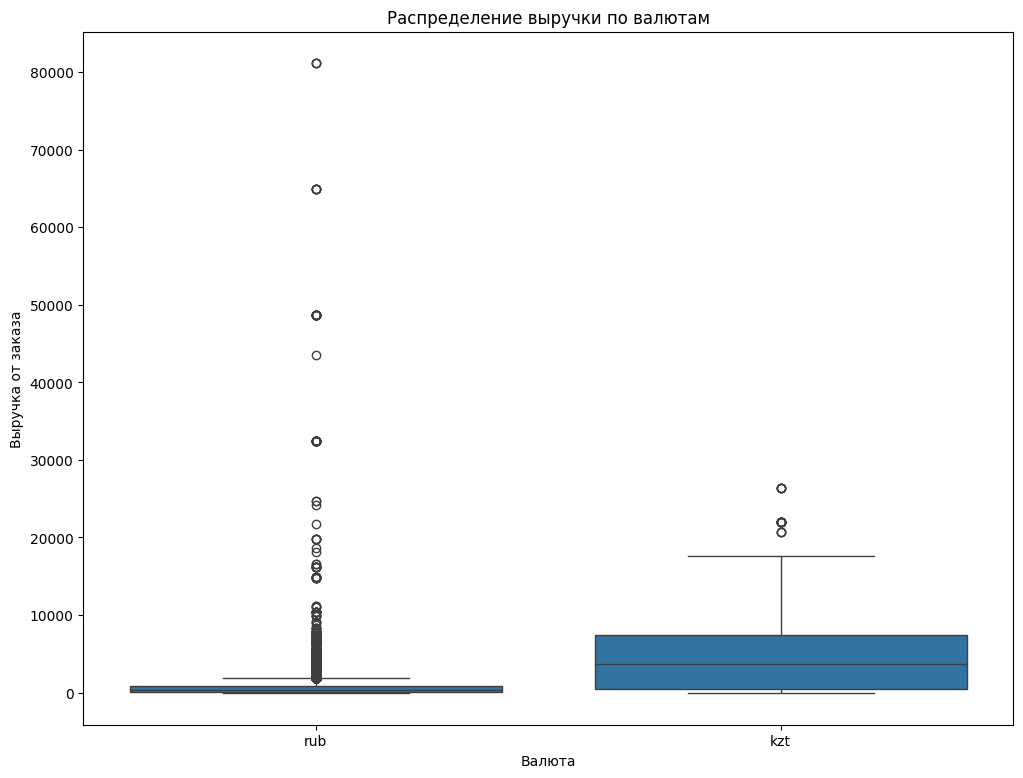

In [28]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
sns.boxplot(x='currency_code', y='revenue', data=merged_df)

# Настраиваем оформление графика
plt.title('Распределение выручки по валютам')
plt.xlabel('Валюта')
plt.ylabel('Выручка от заказа')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В RUB преобладают мелкие заказы, в KZT — более крупные

- Распределение выручки в KZT более стабильно (меньше выбросов), в RUB — более волатильно

- Распределение RUB более асимметрично (левостороннее смещение), в то время как KZT ближе к симметричному.

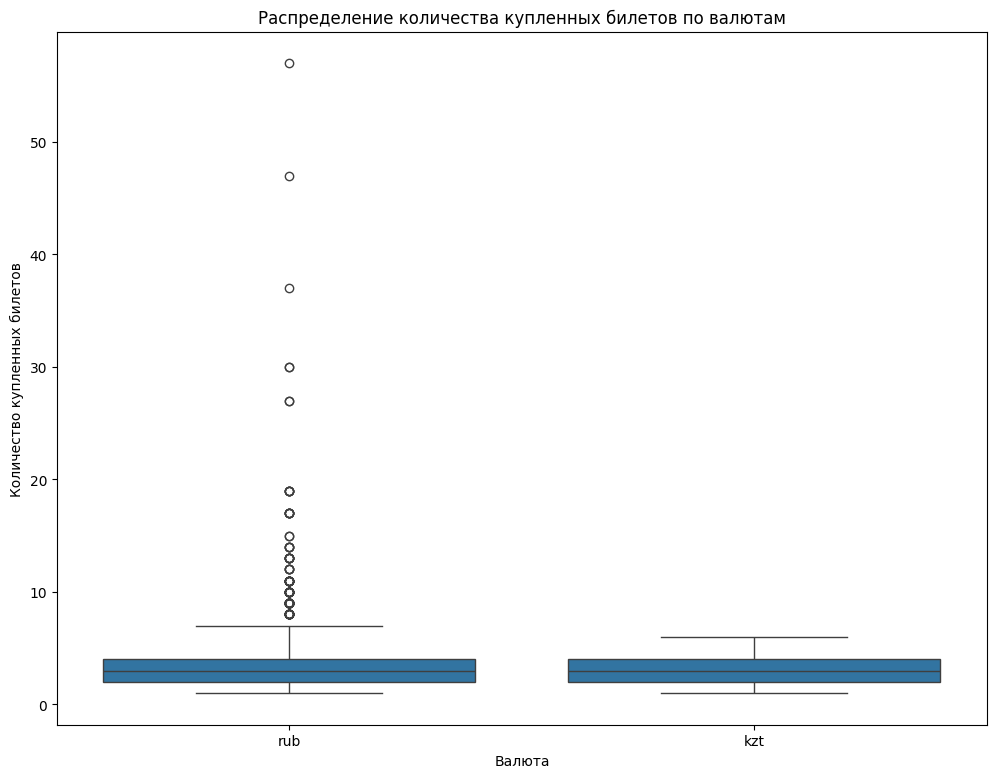

In [29]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
sns.boxplot(x='currency_code', y='tickets_count', data=merged_df)

# Настраиваем оформление графика
plt.title('Распределение количества купленных билетов по валютам')
plt.ylabel('Количество купленных билетов')
plt.xlabel('Валюта')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- График демонстрирует значительное различие в распределении количества билетов между двумя валютами

- Для RUB наблюдается большой разброс значений и наличие множества выбросов (точек за пределами «усов» ящика), что указывает на неравномерность в количестве купленных билетов

- Для KZT распределение выглядит более компактным и стабильным — выбросов практически нет, «ящик» узкий.

In [30]:
# Вычисляем 99 процентиль для RUB и фильтруем данные
rub_99 = rub_orders['revenue'].quantile(0.99)
filter_rub_data = rub_orders[rub_orders['revenue'] <= rub_99]

# Вычисляем 99 процентиль для KZT и фильтруем данные
kzt_99 = kzt_orders['revenue'].quantile(0.99)
filter_kzt_data = kzt_orders[kzt_orders['revenue'] <= kzt_99]

# Выводим резульат
print(f'99-й перцентиль revenue (rub): {rub_99:.2f} руб. \nОтсечено {len(rub_orders)-len(filter_rub_data)} заказов.')
print(f'\n99-й перцентиль revenue (kzt): {kzt_99:.2f} тенге. \nОтсечено {len(kzt_orders)-len(filter_kzt_data)} заказов.')

99-й перцентиль revenue (rub): 2570.80 руб. 
Отсечено 2800 заказов.

99-й перцентиль revenue (kzt): 17617.24 тенге. 
Отсечено 29 заказов.


In [31]:
# Проверка отрицательных значений
neg_rub = (rub_orders['revenue'] < 0).sum()
neg_kzt = (kzt_orders['revenue'] < 0).sum()

# Выводим результат
print(f'Отрицательных заказов в рублях: {neg_rub} ({neg_rub/len(rub_orders)*100:.3f}%)')
print(f'Отрицательных заказов в тенге: {neg_kzt} ({neg_kzt/len(kzt_orders)*100:.3f}%)')

Отрицательных заказов в рублях: 381 (0.133%)
Отрицательных заказов в тенге: 0 (0.000%)


In [32]:
# Удаляем отрицательные значения
filter_rub_data = filter_rub_data[filter_rub_data['revenue'] > 0]

In [33]:
clean_merged_df = pd.concat([filter_rub_data, filter_kzt_data], ignore_index=True)
print(f'Общий размер после очистки: {len(clean_merged_df)} (было {len(merged_df)})')

Общий размер после очистки: 281881 (было 290611)


### 2.4. Проверка на явные и неявные дубликаты

In [34]:
# Проверим на полные дубликаты датафрейм clean_merged_df
clean_merged_df.duplicated().sum()

np.int64(0)

In [35]:
# Проверим на полные дубликаты датафрейм final_tickets_tenge_df
final_tickets_tenge_df.duplicated().sum()

np.int64(0)

In [36]:
# Проверим, есть ли полные дубликаты в заказах
clean_merged_df['order_id'].duplicated().sum()

np.int64(0)

In [37]:
# Проверим на неявные дебликаты по бронированию билета без учета идентификатора заказа
clean_merged_df.duplicated(subset=['user_id', 'created_ts_msk', 'event_id', 'revenue', 'tickets_count', 'total', 'event_name', 'event_type_main', 'region_name', 'city_name', 'venue_name', 'venue_address']).sum()

np.int64(41)

In [38]:
# Удалим неполные дубликаты, оставив только первое вхождение
clean_merged_df_final = clean_merged_df.drop_duplicates(subset=['user_id', 'created_ts_msk', 'event_id', 'revenue', 'tickets_count', 'total', 'event_name', 'event_type_main', 'region_name', 'city_name', 'venue_name', 'venue_address'], keep='first').copy()

# Выводим результат
print(f'Было строк: {len(clean_merged_df_final)}, стало: {len(clean_merged_df)}')

Было строк: 281840, стало: 281881


In [39]:
# Преобразуем к типу даты и времени столбец created_ts_msk
clean_merged_df_final['created_ts_msk'] = pd.to_datetime(clean_merged_df_final['created_ts_msk'])

# Сортируем
clean_merged_df_final = clean_merged_df_final.sort_values(['user_id', 'created_ts_msk'])

# Вычисляем days_since_prev векторизованно
clean_merged_df_final['days_since_prev'] = (clean_merged_df_final.groupby('user_id')['created_ts_msk'].diff().dt.days)

# Выводим результат
clean_merged_df_final[['user_id', 'created_ts_msk', 'days_since_prev']].sort_values(by='created_ts_msk').head(10)

,user_id,created_ts_msk,days_since_prev
271781,fd4d47438ebb946,2024-06-01 00:00:42,NaN
271782,fd4d47438ebb946,2024-06-01 00:01:30,0.0
113696,57ef0a1905ac488,2024-06-01 00:01:58,NaN
271784,fd4d47438ebb946,2024-06-01 00:03:13,0.0
251993,e73089d7d016cd8,2024-06-01 00:03:34,NaN
35891,18e9aead0a393e7,2024-06-01 00:04:54,NaN
271783,fd4d47438ebb946,2024-06-01 00:05:03,0.0
26062,0e6fa925c5f346f,2024-06-01 00:05:17,NaN
26063,0e6fa925c5f346f,2024-06-01 00:08:58,0.0
157435,868ed3e1cd9eb1b,2024-06-01 00:09:38,NaN


### 2.5. Типы данных

In [40]:
# Преобразуем к типу даты и времени
clean_merged_df_final['created_dt_msk'] = pd.to_datetime(clean_merged_df_final['created_dt_msk'])

final_tickets_tenge_df['data'] = pd.to_datetime(final_tickets_tenge_df['data'])

In [41]:
# Понижаем размерность
for col in ['age_limit', 'event_id', 'tickets_count', 'city_id', 'venue_id']:
    clean_merged_df_final[col] = pd.to_numeric(clean_merged_df_final[col], downcast='integer')

### 2.6. Создание новых столбцов

In [42]:
# Добавляем курс
orders_with_cur = clean_merged_df_final.merge(
    final_tickets_tenge_df[['data', 'curs']],
    left_on='created_dt_msk',
    right_on='data',
    how='left'
)

In [43]:
# Приведем выручку заказа к единой валюте(RUB)
orders_with_cur['revenue_rub'] = orders_with_cur['revenue']
mask = orders_with_cur['currency_code'] == 'kzt'
orders_with_cur.loc[mask, 'revenue_rub'] = orders_with_cur.loc[mask, 'revenue'] * (orders_with_cur.loc[mask, 'curs'] / 100)

In [44]:
# Создадим новый столбец one_ticket_revenue_rub
orders_with_cur['one_ticket_revenue_rub'] = orders_with_cur['revenue_rub'] / orders_with_cur['tickets_count']

In [45]:
# Создадим новый столбец month
orders_with_cur['month'] = orders_with_cur['created_dt_msk'].dt.month

In [46]:
# Функция для создания столбца season
def get_season(month):
    if 3 <= month <= 5:
        return 'весна'
    elif 6 <= month <= 8:
        return 'лето'
    elif 9 <= month <= 11:
        return 'осень'
    else:  
        return 'зима'

orders_with_cur['season'] = orders_with_cur['month'].apply(get_season)

In [47]:
# Выводим первые строки датафрейма на экран
orders_with_cur.head()

,Unnamed: 0_x,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,...,city_id,venue_id,venue_name,venue_address,data,curs,revenue_rub,one_ticket_revenue_rub,month,season
0,0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,...,213,3972,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",2024-08-20,18.6972,1521.94,380.4850,8,лето
1,1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,...,213,2941,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",2024-07-23,18.3419,289.45,144.7250,7,лето
2,2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,...,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475,1258.57,314.6425,10,осень
3,3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,...,2,3574,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",2024-07-13,18.5010,8.49,4.2450,7,лето
4,4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,...,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648,1390.41,463.4700,10,осень


**Промежуточный вывод:**

- Выгрузка данных из SQL была успешной, так как кроме столбца `days_since_prev`, данные не содержат пропуски

- При анализе категориальных столбцов, было выявлено, что стобцы содержат корректные уникальные значения и не содержать значения, которые могут обозначать пропуски в данных или отсутствие информации

- Заказы в рублях более разнородны по числу билетов: встречаются как одиночные билеты, так и групповые покупки (что типично для массовых событий – ёлки, спортивные матчи). В тенге же преобладают небольшие заказы (вероятно, связанные с камерными мероприятиями или спецификой рынка Казахстана).

- Отсечение по 99-му перцентилю удалило 2800 рублёвых заказов (около 0.98%) и только 29 тенговых (0.57%)

- Также было отфильтрованы данные с отрицательной выручкой в рублях (0,133%), так как с выручкой в тенге отрицательных значений нет

- При проверке двух датафреймов явных дубликатов выявлено не было

- При проверке датафрейма на неявные дубликаты по бронированию билета без учёта идентификаторов заказа было выявлено 43 дубликата. В следствие чего, они были удалены

- Пересчитать `days_since_prev` после удаления неявных дубликатов

- Столбцы `created_ts_msk` и `created_dt_msk` из датафрейма `clean_merged_df_final`, так же как и столбец `data` из датафрейма `final_tickets_tenge_df`, были приведены к типу данных даты и времени

- У столбцов `age_limit`, `event_id`, `tickets_count`, `city_id`, `venue_id` датафрейма `clean_merged_df_final` была понижена размерность

- Были созданы новые столбцы `revenue_rub`, `one_ticket_revenue_rub`, `month` и `season`

## 3. Исследовательский анализ данных

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

In [48]:
# Для каждого месяца считаем количество заказоа
orders_in_month = orders_with_cur.groupby('month').agg(orders_count = ('order_id', 'nunique')).sort_values(by='orders_count', ascending=False).reset_index()

# Выводим результат
orders_in_month

,month,orders_count
0,10,98997
1,9,68890
2,8,43172
3,7,37882
4,6,32899


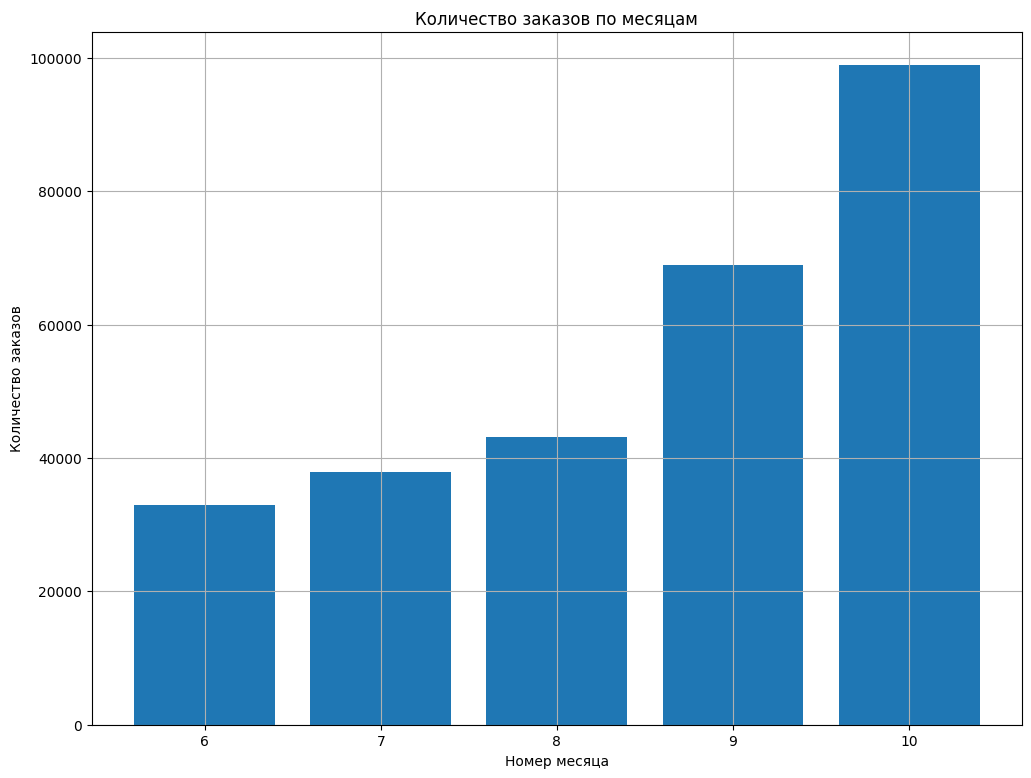

In [49]:
# Задаем размер графика
plt.figure(figsize = (12, 9))

# Строим столбчатую диаграмму
plt.bar(orders_in_month['month'], orders_in_month['orders_count'])

# Настраиваем оформление графика
plt.title('Количество заказов по месяцам')
plt.xlabel('Номер месяца')
plt.ylabel('Количество заказов')

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Наблюдается устойчивый рост количества заказов с июня по октябрь

- Динамика имеет выраженную положительную тенденцию — с каждым месяцем количество заказов увеличивается

In [50]:
# Разделим данные на летний и осенний периоды
summer_period = orders_with_cur[orders_with_cur['season'] == 'лето']
autumn_period = orders_with_cur[orders_with_cur['season'] == 'осень']

In [51]:
# Общее число заказов летом и осенью
summer_total = summer_period['order_id'].nunique()
autumn_total = autumn_period['order_id'].nunique()

# Выводим результат
print(f'Всего заказов летом: {summer_total}')
print(f'Всего заказов осенью: {autumn_total}')

Всего заказов летом: 113953
Всего заказов осенью: 167887


In [52]:
# Для каждого типа мероприятия считаем количество заказов в летний период
summer_event_type = summer_period.groupby('event_type_main').agg(orders_summer=('order_id', 'nunique')).sort_values(by='orders_summer', ascending=False).reset_index()

# Выводим результат
summer_event_type

,event_type_main,orders_summer
0,концерты,49984
1,другое,28483
2,театр,23698
3,стендап,6346
4,спорт,2762
5,выставки,2407
6,ёлки,273


In [53]:
# Для каждого типа мероприятия считаем количество заказов в осенний период
autumn_event_type = autumn_period.groupby('event_type_main').agg(orders_autumn=('order_id', 'nunique')).sort_values(by='orders_autumn', ascending=False).reset_index()

# Выводим результат
autumn_event_type

,event_type_main,orders_autumn
0,концерты,62721
1,театр,42707
2,другое,32667
3,спорт,18776
4,стендап,6923
5,выставки,2402
6,ёлки,1691


In [54]:
# Считаем долю заказов для каждого типа мероприятия
summer_event_type['share_summer'] = summer_event_type['orders_summer'] / summer_total
autumn_event_type['share_autumn'] = autumn_event_type['orders_autumn'] / autumn_total

In [55]:
# Объединяем датафреймы по event_type_main
event_comparison = summer_event_type[['event_type_main', 'share_summer']].merge(
    autumn_event_type[['event_type_main', 'share_autumn']],
    on='event_type_main',
    how='outer'
).fillna(0)

# Устанавливаем event_type_main как индекс
df_shares_1 = event_comparison.set_index('event_type_main')

# Переименовываем столбцы
df_shares_1 = df_shares_1.rename(columns={'share_summer': 'Лето', 'share_autumn': 'Осень'})

# Выводим результат
df_shares_1.sort_values(by='Лето', ascending=False)

,Лето,Осень
event_type_main,,
концерты,0.438637,0.373591
другое,0.249954,0.194577
театр,0.207963,0.254379
стендап,0.055690,0.041236
спорт,0.024238,0.111837
выставки,0.021123,0.014307
ёлки,0.002396,0.010072


<Figure size 1000x600 with 0 Axes>

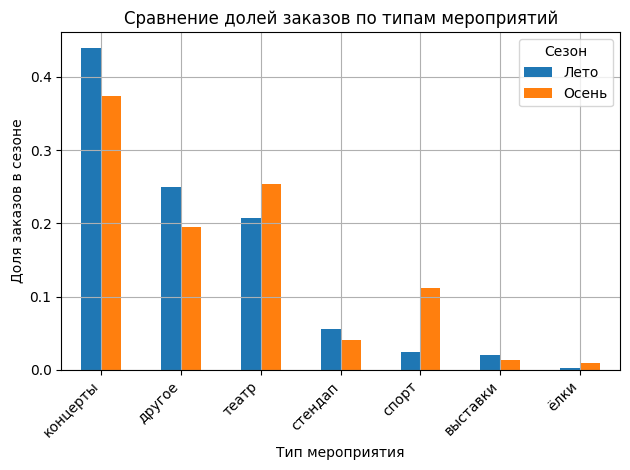

In [56]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
df_shares_1.sort_values(by='Лето', ascending=False).plot(kind='bar')

# Настраиваем оформление графика
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов в сезоне')
plt.title('Сравнение долей заказов по типам мероприятий')
plt.legend(title='Сезон')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В обоих сезонах доминируют концерты и мероприятия категории «другое»

- Наименьшую долю занимают ёлки (характерны преимущественно для осенне-зимнего периода подготовки к Новому году) и выставки

In [57]:
# Для каждого типа устройства считаем количество заказов в летний период
summer_device = summer_period.groupby('device_type_canonical').agg(orders_summer=('order_id', 'nunique')).sort_values(by='orders_summer', ascending=False).reset_index()

# Выводим результат
summer_device

,device_type_canonical,orders_summer
0,mobile,92173
1,desktop,21780


In [58]:
# Для каждого типа устройства считаем количество заказов в осенний период
autumn_device = autumn_period.groupby('device_type_canonical').agg(orders_autumn=('order_id', 'nunique')).sort_values(by='orders_autumn', ascending=False).reset_index()

# Выводим результат
autumn_device

,device_type_canonical,orders_autumn
0,mobile,133648
1,desktop,34239


In [59]:
# Считаем долю заказов для каждого типа устройства
summer_device['share_summer'] = summer_device['orders_summer'] / summer_total
autumn_device['share_autumn'] = autumn_device['orders_autumn'] / autumn_total

In [60]:
# Объединяем датафреймы по device_type_canonical
event_comparison = summer_device[['device_type_canonical', 'share_summer']].merge(
    autumn_device[['device_type_canonical', 'share_autumn']],
    on='device_type_canonical',
    how='outer'
).fillna(0)

# Устанавливаем event_type_main как индекс
df_shares_2 = event_comparison.set_index('device_type_canonical')

# Переименовываем столбцы
df_shares_2 = df_shares_2.rename(columns={'share_summer': 'Лето', 'share_autumn': 'Осень'})

# Выводим результат
df_shares_2

,Лето,Осень
device_type_canonical,,
desktop,0.191131,0.203941
mobile,0.808869,0.796059


<Figure size 1000x600 with 0 Axes>

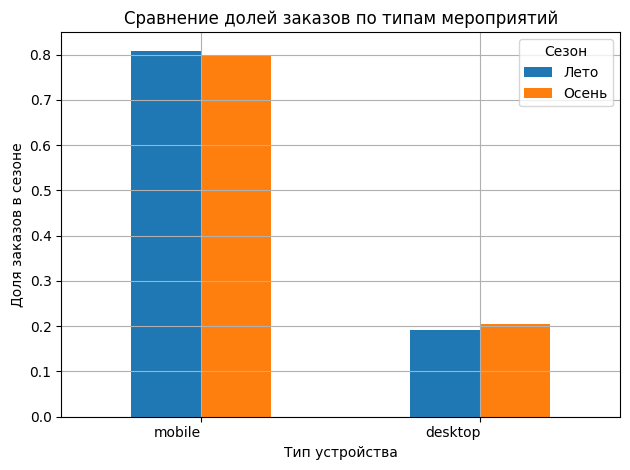

In [61]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
df_shares_2.sort_values(by='Лето', ascending=False).plot(kind='bar')

# Настраиваем оформление графика
plt.xlabel('Тип устройства')
plt.ylabel('Доля заказов в сезоне')
plt.title('Сравнение долей заказов по типам мероприятий')
plt.legend(title='Сезон')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В обоих сезонах мобильные устройства (mobile) значительно доминируют над десктопами (desktop) — это ключевая тенденция

- Доля заказов с мобильных устройств превышает 80% в оба сезона, что подчёркивает важность мобильной доступности сервиса

In [62]:
# Для каждой категории мероприятия по возрастному рейтингу считаем количество заказов в летний период
summer_age_limit = summer_period.groupby('age_limit').agg(orders_summer=('order_id', 'nunique')).sort_values(by='orders_summer', ascending=False).reset_index()

# Выводим результат
summer_age_limit

,age_limit,orders_summer
0,16,32389
1,12,24205
2,6,20880
3,0,20665
4,18,15814


In [63]:
# Для каждой категории мероприятия по возрастному рейтингу считаем количество заказов в осенний период
autumn_age_limit = autumn_period.groupby('age_limit').agg(orders_autumn=('order_id', 'nunique')).sort_values(by='orders_autumn', ascending=False).reset_index()

# Выводим результат
autumn_age_limit

,age_limit,orders_autumn
0,16,44202
1,0,39283
2,12,37225
3,6,29639
4,18,17538


In [64]:
# Считаем долю заказов для каждой категории мероприятия по возрастному рейтенгу
summer_age_limit['share_summer'] = summer_age_limit['orders_summer'] / summer_total
autumn_age_limit['share_autumn'] = autumn_age_limit['orders_autumn'] / autumn_total

In [65]:
# Объединяем датафреймы по age_limit
event_comparison = summer_age_limit[['age_limit', 'share_summer']].merge(
    autumn_age_limit[['age_limit', 'share_autumn']],
    on='age_limit',
    how='outer'
).fillna(0)

# Устанавливаем event_type_main как индекс
df_shares_3 = event_comparison.set_index('age_limit')

# Переименовываем столбцы
df_shares_3 = df_shares_3.rename(columns={'share_summer': 'Лето', 'share_autumn': 'Осень'})

# Выводим результат
df_shares_3

,Лето,Осень
age_limit,,
0,0.181347,0.233985
6,0.183233,0.176541
12,0.212412,0.221727
16,0.284231,0.263284
18,0.138777,0.104463


<Figure size 1000x600 with 0 Axes>

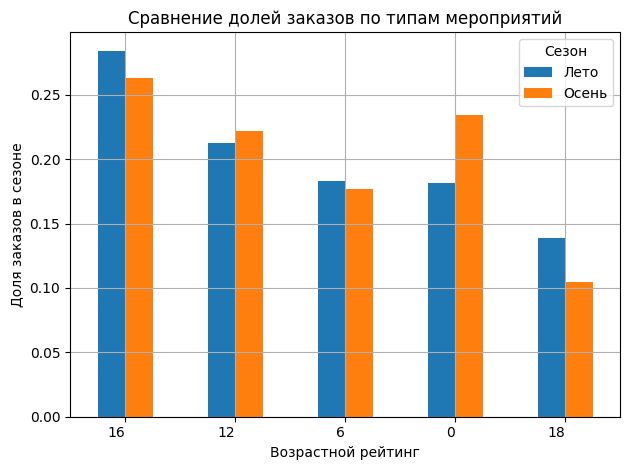

In [66]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
df_shares_3.sort_values(by='Лето', ascending=False).plot(kind='bar')

# Настраиваем оформление графика
plt.xlabel('Возрастной рейтинг')
plt.ylabel('Доля заказов в сезоне')
plt.title('Сравнение долей заказов по типам мероприятий')
plt.legend(title='Сезон')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- В обоих сезонах наиболее востребованы мероприятия с рейтингами 0, 6, 12 и 16

- Мероприятия с рейтингом 18 имеют наименьшую долю заказов, что указывает на меньшую востребованность среди аудитории

In [67]:
# Для каждого типа мероприятия и сезона считаем среднее значение для выручки с одного билета
tickets_price_in_season = orders_with_cur.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().reset_index()

# Выводим результат
tickets_price_in_season

,event_type_main,season,one_ticket_revenue_rub
0,выставки,лето,86.744476
1,выставки,осень,91.905093
2,другое,лето,88.002735
3,другое,осень,77.421380
4,концерты,лето,309.553830
5,концерты,осень,268.424928
6,спорт,лето,55.247119
7,спорт,осень,50.246679
8,стендап,лето,218.518107
9,стендап,осень,231.124973


In [68]:
# Создаем сводную таблицу
pivot_price = tickets_price_in_season.pivot(index='event_type_main', columns='season', values='one_ticket_revenue_rub').fillna(0)
pivot_price = pivot_price[['лето', 'осень']]

# Выводим результат
pivot_price

season,лето,осень
event_type_main,,
выставки,86.744476,91.905093
другое,88.002735,77.421380
концерты,309.553830,268.424928
спорт,55.247119,50.246679
стендап,218.518107,231.124973
театр,216.352713,176.084223
ёлки,271.436176,229.585589


In [69]:
# Считаем относительное изменение осенних значений по сравнению с летними
pivot_price['relative_change'] = round((pivot_price['осень'] - pivot_price['лето']) / pivot_price['лето'] * 100, 2)

# Выводим результат
pivot_price

season,лето,осень,relative_change
event_type_main,,,
выставки,86.744476,91.905093,5.95
другое,88.002735,77.421380,-12.02
концерты,309.553830,268.424928,-13.29
спорт,55.247119,50.246679,-9.05
стендап,218.518107,231.124973,5.77
театр,216.352713,176.084223,-18.61
ёлки,271.436176,229.585589,-15.42


In [70]:
# Удаляем столбец relative_change
df_ticket_price = pivot_price.drop(columns=('relative_change'))

# Выводим результат
df_ticket_price

season,лето,осень
event_type_main,,
выставки,86.744476,91.905093
другое,88.002735,77.421380
концерты,309.553830,268.424928
спорт,55.247119,50.246679
стендап,218.518107,231.124973
театр,216.352713,176.084223
ёлки,271.436176,229.585589


<Figure size 1000x600 with 0 Axes>

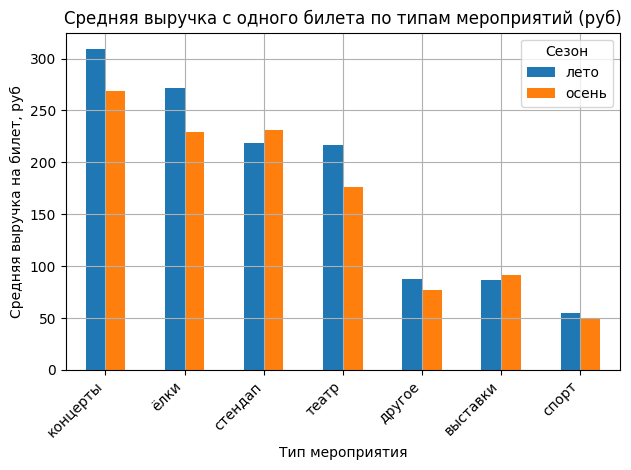

In [71]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
df_ticket_price.sort_values(by='лето', ascending=False).plot(kind='bar')

# Настраиваем оформление графика
plt.xlabel('Тип мероприятия')
plt.ylabel('Средняя выручка на билет, руб')
plt.title('Средняя выручка с одного билета по типам мероприятий (руб)')
plt.legend(title='Сезон')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Концерты, ёлки, театр демонстрируют более выраженную сезонность — летом выручка выше, осенью происходит спад

- Выставки, «другое», спорт показывают меньшую зависимость от сезона — динамика более стабильная, колебания незначительны.

- У стендапа выручка осенью выше, по сравнению с летом

In [72]:
# Копируем значения relative_change из pivot_price
df_relative_change = pivot_price['relative_change'].copy()

# Выводим результат
df_relative_change

event_type_main
выставки     5.95
другое     -12.02
концерты   -13.29
спорт       -9.05
стендап      5.77
театр      -18.61
ёлки       -15.42
Name: relative_change, dtype: float64

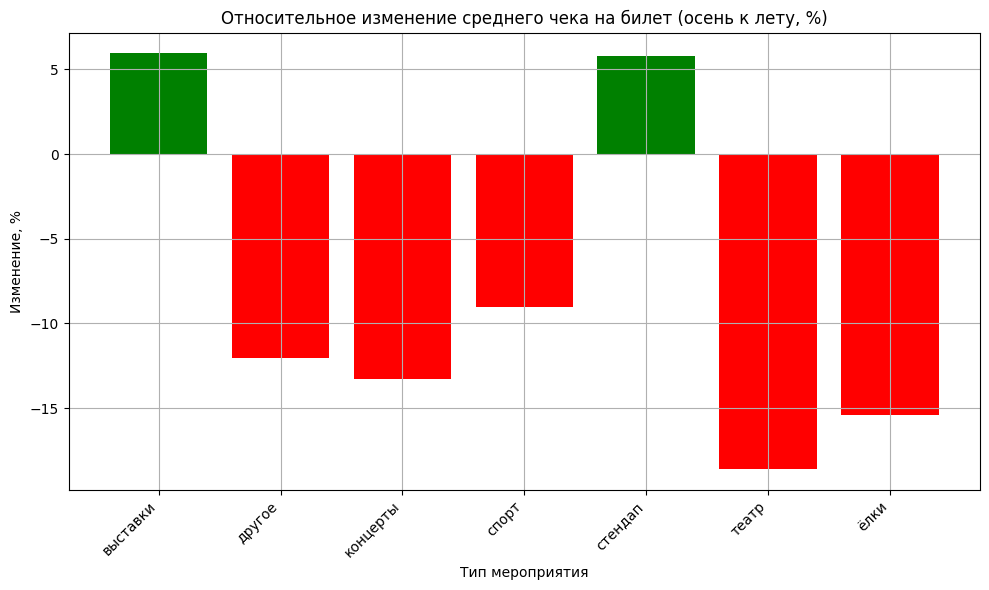

In [73]:
# Задаем размер графика
plt.figure(figsize=(10, 6))

# Строим столбчатую диаграмму
colors = ['green' if x > 0 else 'red' for x in df_relative_change]
plt.bar(df_relative_change.index, df_relative_change.values, color=colors)

# Настраиваем оформление графика
plt.title('Относительное изменение среднего чека на билет (осень к лету, %)')
plt.xlabel('Тип мероприятия')
plt.ylabel('Изменение, %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- График наглядно демонстрирует, что большинство категорий мероприятий продемонстрировали снижение среднего чека осенью по сравнению с летом (отмечено красным цветом). Лишь две категории показали рост (зелёный цвет): выставки(+4,85%) и стендап(+5,77%)

- Самое существенное падение наблюдается у театра(-17,82%)

- Ёлки (–15,42%) — логичное снижение, так как это предновогодний формат, не характерный для осени

### 3.2. Осенняя активность пользователей

In [74]:
# Отбираем только осенний период
autumn_season = orders_with_cur[(orders_with_cur['season'] == 'осень') & (orders_with_cur['month'].isin([9, 10]))].copy()

# Выводим первые строки датафрейма на экран
autumn_season.head()

,Unnamed: 0_x,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,...,city_id,venue_id,venue_name,venue_address,data,curs,revenue_rub,one_ticket_revenue_rub,month,season
2,2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,...,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475,1258.57,314.642500,10,осень
4,4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,...,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648,1390.41,463.470000,10,осень
5,5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,...,193,930,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",2024-10-23,20.0531,902.74,300.913333,10,осень
7,7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,...,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",2024-09-29,19.3741,47.78,47.780000,9,осень
8,8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,...,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",2024-10-15,19.7185,74.84,37.420000,10,осень


In [75]:
# Для каждого осеннего дня считаем количество заказов, уникальное количество пользователей, среднюю стоимость одного заказа
stats_days = autumn_season.groupby('created_dt_msk').agg(orders_count=('order_id', 'count'),
                                                         dau=('user_id', 'nunique'),
                                                         avg_ticket_price=('one_ticket_revenue_rub', 'mean')).reset_index()

# Выводим первые строки датафрейма на экран
stats_days.head()

,created_dt_msk,orders_count,dau,avg_ticket_price
0,2024-09-01,1314,555,202.149068
1,2024-09-02,1370,571,190.847822
2,2024-09-03,5090,776,80.713513
3,2024-09-04,1758,684,179.567815
4,2024-09-05,1940,738,189.902316


In [76]:
# Добавляем новый столбец со средним числом заказа на одного пользователя
stats_days['orders_per_user'] = stats_days['orders_count'] / stats_days['dau']

# Выводим первые строки датафрейма на экран
stats_days.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user
0,2024-09-01,1314,555,202.149068,2.367568
1,2024-09-02,1370,571,190.847822,2.399299
2,2024-09-03,5090,776,80.713513,6.559278
3,2024-09-04,1758,684,179.567815,2.570175
4,2024-09-05,1940,738,189.902316,2.628726


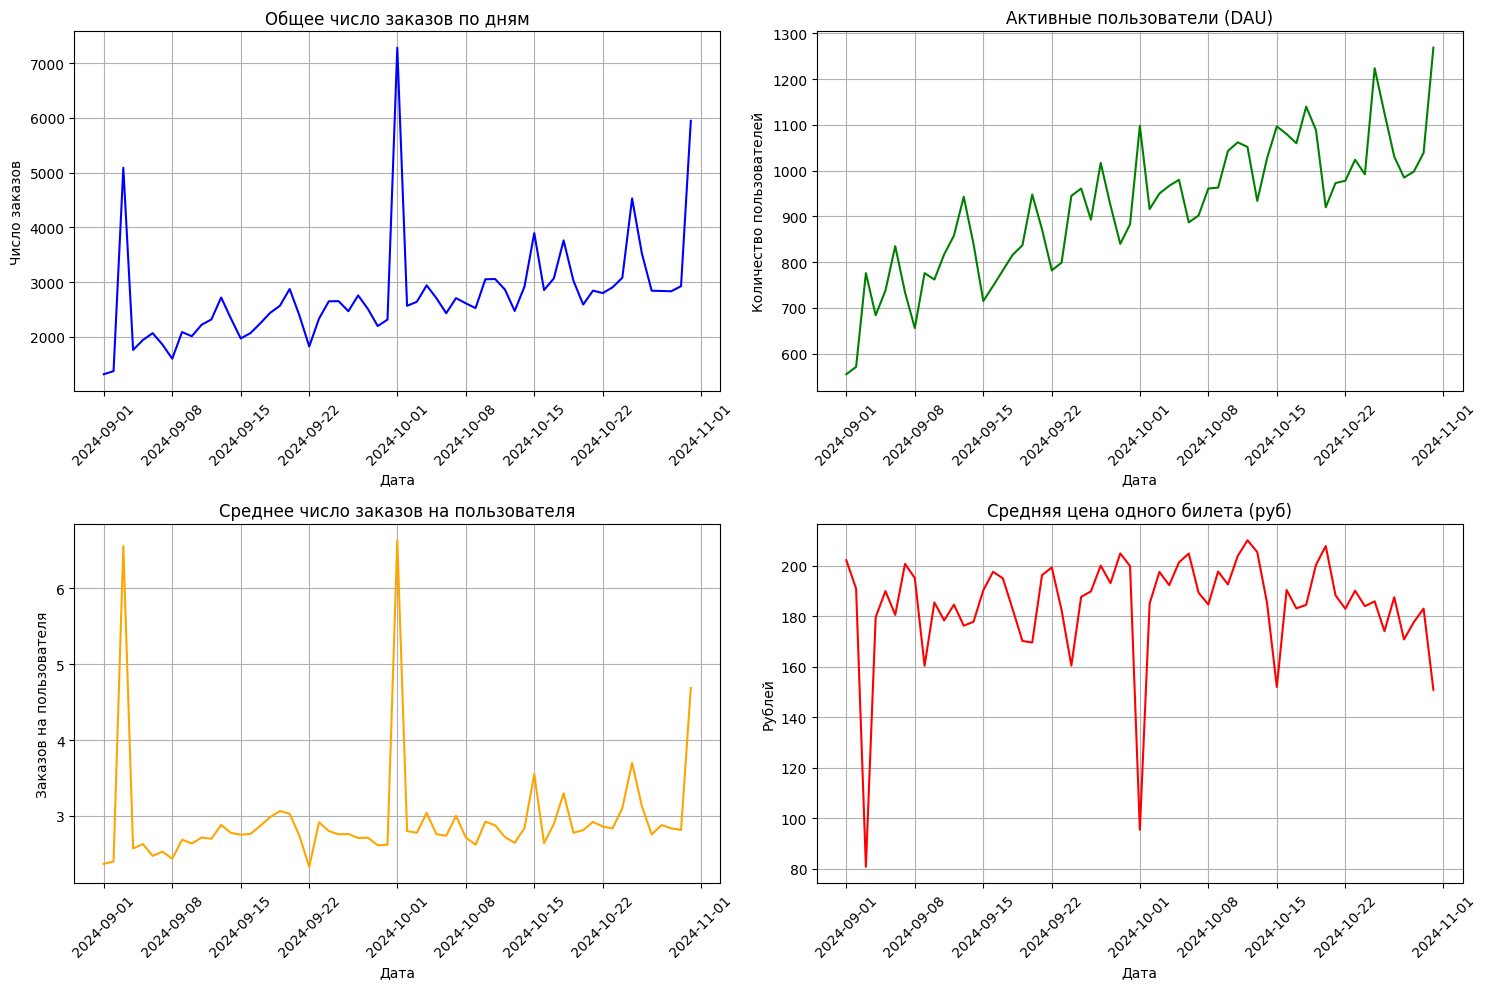

In [77]:
# Задаем размер графиков(формат)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Общее число заказов
axes[0,0].plot(stats_days['created_dt_msk'], stats_days['orders_count'], color='blue')
axes[0,0].set_title('Общее число заказов по дням')
axes[0,0].set_xlabel('Дата')
axes[0,0].set_ylabel('Число заказов')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True)

# 2. DAU
axes[0,1].plot(stats_days['created_dt_msk'], stats_days['dau'], color='green')
axes[0,1].set_title('Активные пользователи (DAU)')
axes[0,1].set_xlabel('Дата')
axes[0,1].set_ylabel('Количество пользователей')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True)

# 3. Среднее число заказов на одного пользователя
axes[1,0].plot(stats_days['created_dt_msk'], stats_days['orders_per_user'], color='orange')
axes[1,0].set_title('Среднее число заказов на пользователя')
axes[1,0].set_xlabel('Дата')
axes[1,0].set_ylabel('Заказов на пользователя')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True)

# 4. Средняя стоимость билета
axes[1,1].plot(stats_days['created_dt_msk'], stats_days['avg_ticket_price'], color='red')
axes[1,1].set_title('Средняя цена одного билета (руб)')
axes[1,1].set_xlabel('Дата')
axes[1,1].set_ylabel('Рублей')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(True)

plt.tight_layout()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Общее число заказов по дням

    - Наблюдается высокая волатильность: резкие пики и спады числа заказов. Например, значительный всплеск заказов около 7000 в середине сентября

    - Средние значения колеблются в диапазоне 3000–5000 заказов в день

- Активные пользователи (DAU)

    - Количество активных пользователей постепенно растёт с начала периода (около 600 в начале сентября) до более 1200 к концу октября — началу ноября

    - Динамика относительно стабильная, без резких спадов

    - Тенденция к росту говорит о повышении лояльности аудитории или эффективной работе маркетинговых каналов

- Среднее число заказов на одного пользователя

    - Значения сильно колеблются: от 2–3 заказов на пользователя до пиков около 6–7 заказов

    - В среднем показатель держится на уровне 2–3 заказов

- Средняя цена одного билета

    - Диапазон цен: от 80 до 200 рублей

    - Отмечены значительные колебания:
        
        - высокие цены (около 200 руб.) в начале периода;

        - резкое падение до 80 руб. в середине сентября;
        
        - последующие колебания в диапазоне 160–200 руб.

In [78]:
# Добавляем столбец с номером дня недели (0 - понедельник, 6 - воскресенье)
stats_days['weekday'] = stats_days['created_dt_msk'].dt.dayofweek

# Создаем булевый столбец, который показывает, является ли день выходным
stats_days['weekend'] = stats_days['weekday'] >= 5

# Создаем словарь с названиями дня недели
weekday_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}

# Создаем новый столбец с названиями дня недели
stats_days['weekday_name'] = stats_days['weekday'].map(weekday_names)

# Выводим первые строки датафрейма на экран
stats_days.head()

,created_dt_msk,orders_count,dau,avg_ticket_price,orders_per_user,weekday,weekend,weekday_name
0,2024-09-01,1314,555,202.149068,2.367568,6,True,Вс
1,2024-09-02,1370,571,190.847822,2.399299,0,False,Пн
2,2024-09-03,5090,776,80.713513,6.559278,1,False,Вт
3,2024-09-04,1758,684,179.567815,2.570175,2,False,Ср
4,2024-09-05,1940,738,189.902316,2.628726,3,False,Чт


In [79]:
# Для каждого дня недели считаем среднее количество заказов, среднее количество активных пользователей и среднюю цену билета
weekly_stats = stats_days.groupby('weekday_name').agg(avg_orders=('orders_count', 'mean'),
                                                      avg_dau=('dau', 'mean'),
                                                      avg_ticket_price=('avg_ticket_price', 'mean')).round(2).reset_index()

# Выводим результат
weekly_stats

,weekday_name,avg_orders,avg_dau,avg_ticket_price
0,Вс,2136.11,813.33,199.66
1,Вт,3490.11,933.00,157.11
2,Пн,2385.11,851.56,184.94
3,Пт,3086.62,1017.00,186.58
4,Сб,2649.38,952.12,194.17
5,Ср,2536.56,922.22,186.03
6,Чт,3007.56,960.00,182.48


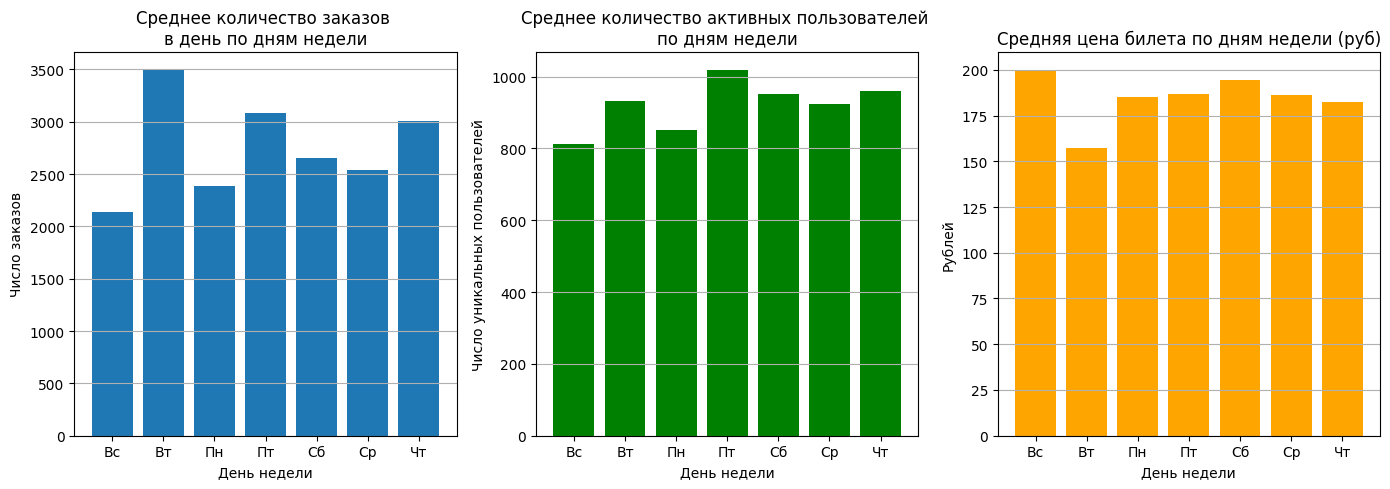

In [80]:
# Задаем размер графиков(формат)
fig, axes = plt.subplots(1, 3, figsize=(14,5))

# 1. Среднее число заказов
axes[0].bar(weekly_stats['weekday_name'], weekly_stats['avg_orders'])
axes[0].set_title('Среднее количество заказов \nв день по дням недели')
axes[0].set_xlabel('День недели')
axes[0].set_ylabel('Число заказов')
axes[0].grid(axis='y')

# 2. Среднее количество активных пользователей
axes[1].bar(weekly_stats['weekday_name'], weekly_stats['avg_dau'], color='green')
axes[1].set_title('Среднее количество активных пользователей \nпо дням недели')
axes[1].set_xlabel('День недели')
axes[1].set_ylabel('Число уникальных пользователей')
axes[1].grid(axis='y')

# 3. Средняя цена билета
axes[2].bar(weekly_stats['weekday_name'], weekly_stats['avg_ticket_price'], color='orange')
axes[2].set_title('Средняя цена билета по дням недели (руб)')
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Рублей')
axes[2].grid(axis='y')

plt.tight_layout()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Среднее количество заказов в день

    - Наибольшее количество заказов наблюдается во вторник. Это может быть связано с началом рабочей недели и планированием досуга на выходные.

    - Второй по объёму день — пятница. Это может отражать подготовку к выходным

    - Наименьший объём заказов приходится на воскресенье. Это, скорее всего, связано с окончанием выходных

- Среднее количество активных пользователей по дням недели

    - Наибольшее количество уникальных пользователей наблюдается во вторник в пятницу

    - Второй по объёму день — четверг

    - Наименьшее количество уникальных пользователей наблюдается в воскресенье

- Средняя цена билета по дням недели

    - Самая высокая средняя цена билета отмечена в воскресенье

    - Наименьшая цена зафиксирована в четверг

In [81]:
# Для выходных и будней считаем среднее количество заказов, среднее количество активных пользователей и среднюю цену билета
weekend_stats = stats_days.groupby('weekend').agg(avg_orders=('orders_count', 'mean'),
                                                      avg_dau=('dau', 'mean'),
                                                      avg_ticket_price=('avg_ticket_price', 'mean')).round(2)

weekend_stats.index = ['Будни', 'Выходные']
weekend_stats = weekend_stats.rename(columns={'avg_orders': 'Среднее количество заказов', 'avg_dau': 'Среднее значение DAU', 'avg_ticket_price': 'Средняя стоимости одного билета.'})

# Выводим результат
weekend_stats

,Среднее количество заказов,Среднее значение DAU,Средняя стоимости одного билета.
Будни,2896.98,934.93,179.27
Выходные,2377.65,878.65,197.08


<Figure size 1400x600 with 0 Axes>

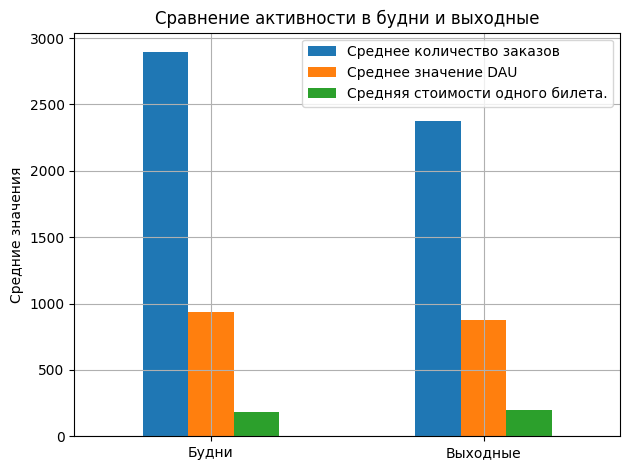

In [82]:
# Задаем размер графика
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму
weekend_stats.plot(kind='bar')

# Настраиваем оформление графика
plt.title('Сравнение активности в будни и выходные')
plt.ylabel('Средние значения')
plt.xticks(rotation=0)

plt.tight_layout()

# Добавляем сетку графика
plt.grid()

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Среднее количество заказов

    - В будни зафиксировано значительно больше заказов (2906,61) по сравнению с выходными (2396,00)

- Среднее количество активных пользователей

    - В будни среднее количество активных пользователей выше (937,41), чем в выходные (887,82)

- Средняя стоимость одного билета

    - В выходные средняя цена билета выше (195,22 руб.), чем в будни (178,61 руб.)

- Будни характеризуются высоким объёмом заказов и активности, но более низкой ценой билета 

- Выходные демонстрируют меньший объём заказов и активности, но более высокую среднюю цену билета

### 3.3. Популярные события и партнёры

In [83]:
# Для каждого региона считаем уникальное количество мероприятий и общее число закакзов
region_stats = autumn_season.groupby('region_name').agg(unique_events=('event_id', 'nunique'),
                                                        orders_count=('order_id', 'count')).sort_values(by='unique_events', ascending=False).reset_index()

# Выводим первые строки датафрейма на экран
region_stats.head()

,region_name,unique_events,orders_count
0,Каменевский регион,3893,46573
1,Североярская область,2597,20626
2,Широковская область,794,8645
3,Светополянский округ,755,4751
4,Речиновская область,529,3565


In [84]:
# Считаем общее число уникальных мероприятий
total_events = region_stats['unique_events'].sum()

# Считаем общее число заказов
total_orders = region_stats['orders_count'].sum()

In [85]:
# Добавляем доли
region_stats['event_share'] = region_stats['unique_events'] / total_events * 100
region_stats['order_share'] = region_stats['orders_count'] / total_orders * 100

In [86]:
# Выводим первые строки датафрейма на экран
region_stats.head(10)

,region_name,unique_events,orders_count,event_share,order_share
0,Каменевский регион,3893,46573,24.679853,27.740683
1,Североярская область,2597,20626,16.463801,12.285645
2,Широковская область,794,8645,5.033600,5.149297
3,Светополянский округ,755,4751,4.786357,2.829880
4,Речиновская область,529,3565,3.353620,2.123452
5,Серебринская область,456,4467,2.890833,2.660718
6,Яблоневская область,431,4196,2.732344,2.499300
7,Тепляковская область,419,2484,2.656270,1.479567
8,Горицветская область,406,3229,2.573856,1.923317
9,Солнечноземская область,401,4193,2.542158,2.497513


**Вывод:**

- Наибольшее разнообразие мероприятий наблюдается в Каменевском регионе – здесь проводится 3910 уникальных событий, что составляет 24,6% от всех мероприятий осени. Доля заказов в этом регионе ещё выше – 27,7%, что говорит о его высокой коммерческой эффективности.

- Второй по разнообразию – Североярская область (2613 событий, 16,5% мероприятий, но только 12,3% заказов). Это указывает на то, что в регионе много событий, но они собирают меньше заказов в среднем.

- Топ-5 регионов по количеству мероприятий охватывают 54% всех уникальных событий и 50% всех заказов.

In [87]:
# Для каждого билетного партнера считаем уникальное количество мероприятий, общее количество заказов и суммарную выручку
partner_stats = autumn_season.groupby('organizers').agg(unique_events=('event_id', 'nunique'),
                                                        orders_count=('order_id', 'count'),
                                                        total_revenue=('revenue_rub', 'sum')).sort_values(by='total_revenue', ascending=False).reset_index()

# Выводим первые строки датафрейма на экран
partner_stats.head()

,organizers,unique_events,orders_count,total_revenue
0,№4054,10,1804,1744174.20
1,№2121,46,4184,1676861.47
2,№894,18,2076,1376775.05
3,№4403,29,1437,1295137.64
4,№1531,62,9329,1031771.47


In [88]:
# Считаем долю выручки каждого партнера а общем объеме выручки (в процентах)
partner_stats['revenue_share'] = partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100

# Выводим первые строки датафрейма на экран
partner_stats.head(10)

,organizers,unique_events,orders_count,total_revenue,revenue_share
0,№4054,10,1804,1744174.20,2.129944
1,№2121,46,4184,1676861.47,2.047743
2,№894,18,2076,1376775.05,1.681285
3,№4403,29,1437,1295137.64,1.581591
4,№1531,62,9329,1031771.47,1.259975
5,№4551,8,916,1003557.96,1.225521
6,№1134,6,1079,889121.91,1.085774
7,№1022,7,736,877634.93,1.071747
8,№1385,3,646,818118.13,0.999066
9,№3502,24,658,798398.35,0.974985


**Вывод:**

- Наиболее активные партнёры по выручке – №4054 (1,74 млн руб, 2,13% доли), №2121 (1,68 млн руб, 2,05%), №894 (1,38 млн руб, 1,68%). Однако лидер по числу обработанных заказов – №1531 (9330 заказов, 1,26% выручки) и по числу уникальных мероприятий – №2121 (46 событий) и №1531 (63 события)

- У некоторых партнёров при небольшом количестве мероприятий высокая выручка (например, №4054 – всего 10 событий, но 1,74 млн руб). Это может означать, что они организуют дорогие или популярные события

- У других (№1531) – много событий и много заказов, но средняя выручка на заказ или билет ниже

## 4. Статистический анализ данных

### 4.1. Среднее количество заказов

In [89]:
# Отбираем данные, только за осенний период
df_autumn_season = orders_with_cur[(orders_with_cur['season'] == 'осень') & (orders_with_cur['month'].isin([9, 10]))].copy()

# Выводим первые строки датафрейма на экран
df_autumn_season.head()

,Unnamed: 0_x,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,...,city_id,venue_id,venue_name,venue_address,data,curs,revenue_rub,one_ticket_revenue_rub,month,season
2,2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,...,213,4507,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",2024-10-06,19.6475,1258.57,314.642500,10,осень
4,4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,...,240,1896,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",2024-10-04,19.6648,1390.41,463.470000,10,осень
5,5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,...,193,930,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",2024-10-23,20.0531,902.74,300.913333,10,осень
7,7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,...,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",2024-09-29,19.3741,47.78,47.780000,9,осень
8,8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,...,18,3159,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",2024-10-15,19.7185,74.84,37.420000,10,осень


**Односторонний тип гипотезы:**

**H<sub>0</sub> (нулевая гипотеза):** Среднее количество заказов на одного пользователя с мобильных устройств меньше или равно, чем на стационарных

**H<sub>1</sub> (альтернативная гипотеза):** Среднее количество заказов на одного пользователя на мобильных устройствах выше, чем на стационарных.

In [90]:
# Создаём таблицу user_orders, в которой для каждого пользователя и для каждого типа устройства считаем количество заказов
user_orders = df_autumn_season.groupby(['user_id', 'device_type_canonical']).size().unstack(fill_value=0)

# Выводим первые строки датафрейма на экран
user_orders.head()

device_type_canonical,desktop,mobile
user_id,,
0005ca5e93f2cf4,0,1
000898990054619,0,2
000a55a418c128c,0,2
001e7037d013f0f,0,2
00245c702bc343e,0,2


In [91]:
# Считаем пользователей, которые делали заказ с мобильного и стационарного устройств
both = user_orders[(user_orders['mobile'] > 0) & (user_orders['desktop'] > 0)]

# Выводим результат
print(f'Пользователей с обоими устройствами: {len(both)}')
print(f'Доля от общего числа уникальных пользователей: {len(both)/len(user_orders)*100:.1f}%')

Пользователей с обоими устройствами: 3235
Доля от общего числа уникальных пользователей: 20.6%


In [92]:
# Вычисляем разность
user_orders['diff'] = user_orders['mobile'] - user_orders['desktop']

user_orders.head()

device_type_canonical,desktop,mobile,diff
user_id,,,
0005ca5e93f2cf4,0,1,1
000898990054619,0,2,2
000a55a418c128c,0,2,2
001e7037d013f0f,0,2,2
00245c702bc343e,0,2,2


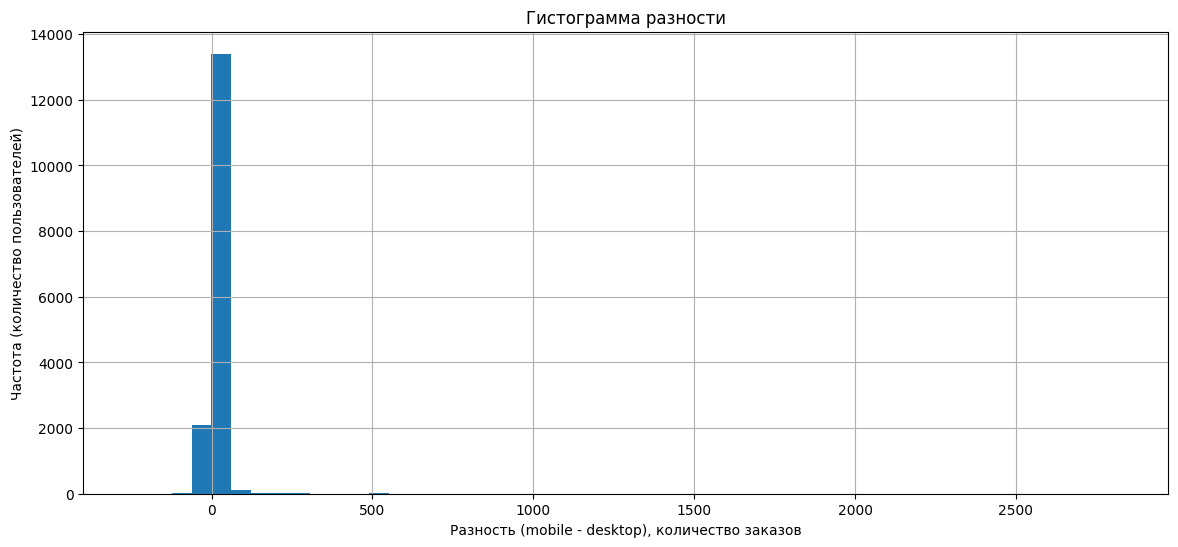

In [93]:
# Задаем размер графика
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму
user_orders['diff'].hist(bins=50)

# Настраиваем оформление графика
plt.title('Гистограмма разности')
plt.xlabel('Разность (mobile - desktop), количество заказов')
plt.ylabel('Частота (количество пользователей)')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Данное распределение не является нормальным

- На данной гистограмме наблюдается острый пик около нуля и резкое падение частоты с увеличением разности (mobile – desktop). Это указывает на асимметричное распределение.

In [94]:
# Для каждого пользователя определяем, каким устройством он пользовался
user_device_list = df_autumn_season.groupby('user_id')['device_type_canonical'].apply(set)

# Количество пользователей только с mobile
mobile_only = user_device_list.apply(lambda x: x == {'mobile'}).sum()

# Количество пользователей только с desktop
desktop_only = user_device_list.apply(lambda x: x == {'desktop'}).sum()

# Количество пользователей с обоими устройствами
both_devices = user_device_list.apply(lambda x: x == {'mobile', 'desktop'}).sum()

print(f'Количество пользователей, которые пользовались только мобильным устройством (mobile): {mobile_only}')
print(f'Количество пользователей, которые пользовались только стационарным устройством (desktop): {desktop_only}')
print(f'Количество пользователей, которые пользовались и мобильными, и стационарными устройствами: {both_devices}')
print(f'Всего уникальных пользователей: {len(user_device_list)}')

Количество пользователей, которые пользовались только мобильным устройством (mobile): 10875
Количество пользователей, которые пользовались только стационарным устройством (desktop): 1627
Количество пользователей, которые пользовались и мобильными, и стационарными устройствами: 3235
Всего уникальных пользователей: 15737


In [95]:
# Считаем среднее значение для пользователей, которые используют ТОЛЬКО мобильные устройства или ТОЛЬКО стационарные
mobile_only_users = user_orders[user_orders['desktop'] == 0]['mobile']
desktop_only_users = user_orders[user_orders['mobile'] == 0]['desktop']

mean_mobile_only = mobile_only_users.mean()
mean_desktop_only = desktop_only_users.mean()
mean_both = both.mean()

print('Среднее количество заказоы:')
print(f'Мобильные устройства (mobile): {mean_mobile_only}')
print(f'Стационарные устройства (desktop): {mean_desktop_only}')
print('\nСреднее количество заказов для мобильный и стационарных устройств:')
print(mean_both)

Среднее количество заказоы:
Мобильные устройства (mobile): 2.866942528735632
Стационарные устройства (desktop): 1.9711124769514443

Среднее количество заказов для мобильный и стационарных устройств:
device_type_canonical
desktop     9.592581
mobile     31.675425
dtype: float64


In [96]:
# Проводим тест Уилкоксона
stat, p_wilcoxon_value = wilcoxon(user_orders['mobile'], user_orders['desktop'], alternative='greater')

print(f'p-value: {p_wilcoxon_value}')

p-value: 0.0


In [97]:
# Задаем уровень значимости
alpha = 0.05

# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if p_wilcoxon_value > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Отвергаем нулевую гипотезу


**Вывод:**

- Применённый критерий: непараметрический критерий Уилкоксона для связанных выборок:

    - Наличия зависимости наблюдений (20.6% пользователей используют оба типа устройств)

    - Отсутствия нормальности распределения разностей (гистограмма асимметрична)

    - Присутствия выбросов 

- Результат теста:

    - p-value = 0.0

    - Уровень значимости равен 0.05

    - Нулевая гипотеза отвергается

### 4.2. Среднее время между заказами

**H<sub>0</sub> (нулевая гипотеза):** Среднее время между заказами у пользователей мобильных устройств не превышает среднее время между заказами у пользователей стационарных устройств.

**H<sub>1</sub> (альтернативная гипотеза):** Среднее время между заказами у пользователей мобильных устройств больше, чем у пользователей стационарных устройств.

In [98]:
# Для каждого пользователя считаем общее количество заказов, количество мобильных заказов и средний интервал между заказами
user_agg = df_autumn_season.groupby('user_id').agg(total_orders=('order_id', 'count'),
                                                   mobile_orders=('device_type_canonical', lambda x: (x == 'mobile').sum()),
                                                   mean_interval=('days_since_prev', 'mean')).reset_index()

# Считаем долю мобильных заказов
user_agg['mobile_share'] = user_agg['mobile_orders'] / user_agg['total_orders']

# Выводим первые строки датафрейма на экран
user_agg.head()

,user_id,total_orders,mobile_orders,mean_interval,mobile_share
0,0005ca5e93f2cf4,1,1,74.0,1.0
1,000898990054619,2,2,50.5,1.0
2,000a55a418c128c,2,2,15.0,1.0
3,001e7037d013f0f,2,2,43.5,1.0
4,00245c702bc343e,2,2,27.0,1.0


In [99]:
# Функция для разделения заказов по устройствам
def allegiance_group(row):
    if row['mobile_orders'] == row['total_orders']:
        return 'mobile_only'
    elif row['mobile_orders'] == 0:
        return 'desktop_only'
    elif row['mobile_share'] >= 0.7:
        return 'mobile_biased'
    elif row['mobile_share'] <= 0.3:
        return 'desktop_biased'
    else:
        return 'mixed'

# Создаем новый столбец и применяем функцию
user_agg['allegiance'] = user_agg.apply(allegiance_group, axis=1)

# Выводим первые строки датафрейма на экран
user_agg.head()

,user_id,total_orders,mobile_orders,mean_interval,mobile_share,allegiance
0,0005ca5e93f2cf4,1,1,74.0,1.0,mobile_only
1,000898990054619,2,2,50.5,1.0,mobile_only
2,000a55a418c128c,2,2,15.0,1.0,mobile_only
3,001e7037d013f0f,2,2,43.5,1.0,mobile_only
4,00245c702bc343e,2,2,27.0,1.0,mobile_only


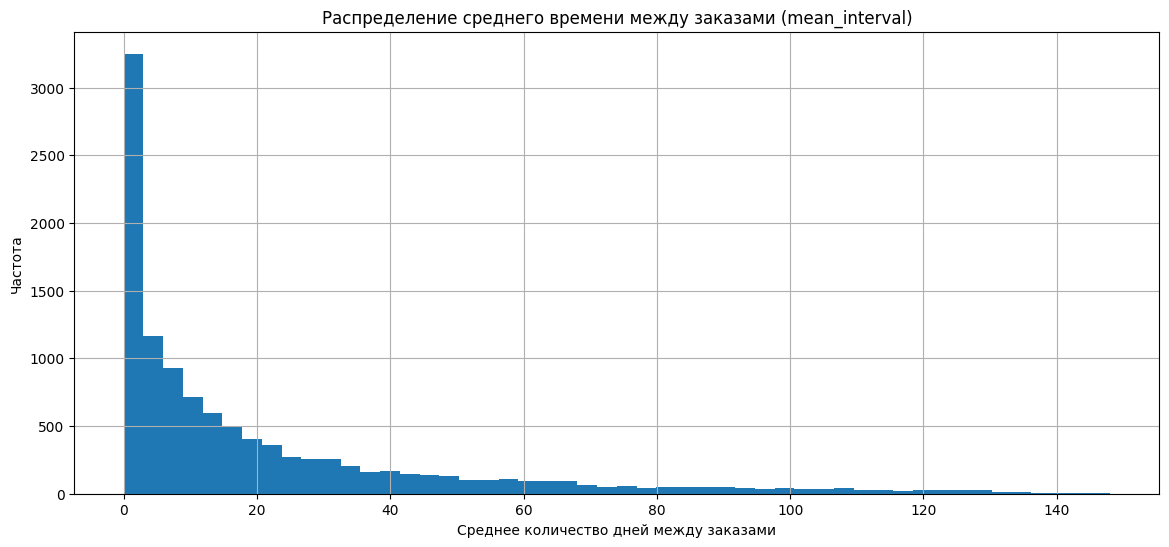

In [100]:
# Задаем размер графика
plt.figure(figsize=(14, 6))

# Строим столбчатую диаграмму
user_agg['mean_interval'].hist(bins=50)

# Настраиваем оформление графика
plt.title('Распределение среднего времени между заказами (mean_interval)')
plt.xlabel('Среднее количество дней между заказами')
plt.ylabel('Частота')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Данное распределение не является нормальным

In [101]:
# Расчёт среднего времени между заказами для каждой группы приверженности
mean_intervals = user_agg.groupby('allegiance')['mean_interval'].mean()

print('Среднее время между заказами (дней) по группам:')
print(mean_intervals.round(2))

Среднее время между заказами (дней) по группам:
allegiance
desktop_biased     8.30
desktop_only      31.45
mixed             15.01
mobile_biased      5.34
mobile_only       24.84
Name: mean_interval, dtype: float64


In [102]:
# Создадим список массивов значений mean_interval для каждой группы
grouped_data = [group['mean_interval'].dropna().values for name, group in user_agg.groupby('allegiance')]

In [103]:
# Критерий Краскела-Уоллиса (для проверки всех групп)
h_stat, p_kruskal_value = kruskal(*grouped_data)
print(f' p_kruskal_value = {p_kruskal_value}')

 p_kruskal_value = 1.6882417789160238e-134


In [104]:
# Попарное сравнение для групп mobile_only и desktop_only
mobile_vals = user_agg[user_agg['allegiance'] == 'mobile_only']['mean_interval'].dropna()
desktop_vals = user_agg[user_agg['allegiance'] == 'desktop_only']['mean_interval'].dropna()

if len(mobile_vals) > 0 and len(desktop_vals) > 0:
    u_stat, mw_p = mannwhitneyu(mobile_vals, desktop_vals)
    print(f' p_mw_value = {mw_p}')
else:
    print('Недостаточно данных для сравнения mobile_only и desktop_only')

 p_mw_value = 0.20505047284625422


In [105]:
# Задаем уровень значимости
alpha = 0.05

# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if p_kruskal_value > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Отвергаем нулевую гипотезу


In [106]:
# Если p-value больше уровня значимости, нет оснований отвергнуть нулевую гипотезу, иначе гипотеза отвергается
if mw_p > alpha:
    print('Нет достаточных оснований для отклонения нулевой гипотезы')
else:
    print('Отвергаем нулевую гипотезу')

Нет достаточных оснований для отклонения нулевой гипотезы


**Вывод:**

- Были применены два теста: тест Краскела-Уоллиса и тест Манна-Уитни:

    - Тест Краскела-Уоллиса:

        - Сравниваются более двух групп

        - Распределение `mean_interval` не является нормальным

        - Присутствуют выбросы

    - Тест Манна-Уитни:

        - Применялся для сравнения двух групп: тех, кто использовал только мобильное устройство (`mobile_vals`) и кто использовал только стационарное устройство (`desktop_vals`), то есть группы являются независимыми

        - Распределение `mean_interval` не является нормальным

        - Присутствуют выбросы

- Результат теста Краскела-Уоллиса:

    - p-value = 1.6882417789160238e-134

    - Уровень значимости равен 0.05

    - Нулевая гипотеза отвергается

- Результат теста Манна-Уитни:

    - p-value = 0.2050505

    - Уровень значимости равен 0.05

    - Нет достаточных оснований для отклонения нулевой гипотезы 

- После проведения двух тестов можно прийти к выводу, что пользователи, придерживающиеся исключительно мобильных или исключительно стационарным устройствам, возвращаются за новыми билетами с примерно одинаковой частотой (p-value > 0,05). Тем не менее, существуют различия в частоте возвратов между «чистыми» и «смешанными» пользователями, а также между группами с разным перекосом в сторону одного из устройств

## 5. Общий вывод и рекомендации

**1. Информация о данных**

В работе использованы три датасета за период 1 июня – 31 октября 2024:

- `final_tickets_orders_df.csv` – 290 849 заказов (после очистки осталось 287 739), содержащий информацию о покупках (выручка, валюта, устройство, возрастной рейтинг, интервал до предыдущей покупки).

- `final_tickets_events_df.csv` – 22 427 событий с детализацией по категориям, организаторам, площадкам, городам и регионам.

- `final_tickets_tenge_df.csv` – курс тенге к рублю за 2024 год для приведения валют к единому знаменателю.

Данные были очищены от дубликатов (43 неявных дубликата), выбросы отсечены по 99-му перцентилю, также были отсечены отрицательные значения выручки в рублях, валюты сконвертированы в рубли. Столбцы с датами приведены к типу datetime, понижена размерность числовых полей.

**2. Основные результаты анализа**

Анализ показал, что сервис Яндекс Афиши за период с июня по октябрь 2024 года пережил структурную перестройку спроса и устойчивый рост аудитории

- Летом доминировали концерты под открытым небом (43% заказов), однако осенью зрители переключились на театр (доля выросла с 20% до 25%) и спорт (доля выросла с 2,5% до 11,2%). Это обусловлено началом театрального и спортивного сезонов

При этом средний чек на театр осенью упал на 18% (вероятно, за счёт более доступных спектаклей для привлечения новой аудитории), тогда как стендап, наоборот, подорожал (+6%)

- 80% заказов совершается с мобильных устройств:

    - Пользователи только мобильных устройств делают в среднем 2,87 заказа за период (сентябрь–октябрь 2024)

    - Пользователи только десктопных устройств – в среднем 1,97 заказа

    - Различие статистически значимо (парный тест Уилкоксона, p‑value ≈ 0,0).

- Интервалы между повторными покупками:

    - Средний интервал у «чистых» мобильных пользователей: 24,8 дня

    - У «чистых» десктопных пользователей средний интервал 31,5 дня.

    - Однако попарное сравнение (Манна–Уитни) этих двух групп не показало статистически значимой разницы (p = 0,205).

- Глобальный тест Краскела–Уоллиса (p ≈ 1,7e-134) выявил различия между всеми пятью группами приверженности. Это означает, что частота возвратов зависит в первую очередь от того, использует ли пользователь оба устройства и насколько силён перекос в сторону одного из них.

**3. Результаты проверки гипотез**

- Гипотеза 1: «Среднее число заказов на одного пользователя у мобильных устройств выше, чем у десктопных».

    - Парный критерий Уилкоксона (тест для связанных выборок) для всех пользователей (включая тех, у кого есть заказы на обоих устройствах)

    - p‑value ≈ 0,0 < 0,05 → нулевая гипотеза отвергается.

    - Вывод: на одного пользователя заказов с мобильных устройств статистически значимо больше, чем с десктопных. Мобильная аудитория активнее.

- Гипотеза 2: «Среднее время между повторными заказами у мобильных пользователей больше, чем у десктопных».

    - Глобальный тест Краскела–Уоллиса (сравнение 5 групп): p ≈ 1,7e-134 – различия между группами статистически значимы.

    - Попарный тест Манна–Уитни (только mobile_only vs desktop_only):p = 0,205 > 0,05, следовательно,  нет оснований отвергнуть нулевую гипотезу

    - Вывод: «Чистые» мобильные и «чистые» десктопные пользователи возвращаются за новыми билетами с одинаковой частотой. Однако пользователи, которые переключаются между устройствами, имеют значительно более длинные интервалы, что и даёт глобальную значимость.

**4. Рекомендации**

- Развивать мобильные платформы, так как мобильные «чистые» пользователи совершают в среднем на 46% больше заказов, чем десктопные «чистые» (2,87 против 1,97)

Ожидается, что будет увеличение среднего числа заказов на мобильного пользователя

- Запустить программу лояльности с учётом паттернов использования устройств, для повышение повторных покупок, так как пользователи, которые переключаются между устройствами, возвращаются реже (интервал 15–31 день)

- Сезонное переключение ассортимента и ценовая адаптация, так как осенью спрос сместился в театр и спорт, причём цена на театр упала, что привлекло новую аудиторию

Ожидается, что будет рост выручки от театра и спорта за счёт привлечения новой аудитории и удержания существующей.